LA FUNZIONE OBIETTIVO MIN-MAX: L'ANIMA MATEMATICA DELLE GAN

Come si parlano il falsario ed il poliziotto per capire cosa sta succedendo?

- Analisi dell'Equazione di Goodfellow (2014)
- Il punto di Equilibrio di Nash e la Convergenza
- Dinamica dei Gradienti e Backpropagation

Generator e Discriminator di allenano in modo alternato
Il Discriminator vuole massimizzare la funzione (vuole trovare sempre più fake) mentre il Generator vuole minimizzarla (vuole che l'immagine fake sia talmente chiara da sembrare reale)
E' il gioco di obiettivi contrapposti

Partiamo dal Discriminator con immagini reali
Facciamo esaminare al discriminatore un'immagine reale
Il Discriminatore produce un numero compreso tra 0 e 1
es.
x=immagine reale 
D(x)=0.95
secondo il Discriminatore (D) l'immagine ha una probabilità molto alta di essere reale.
Il Discriminatore vorrebbe avere sempre valori alti (tendenti a 1) per immagini reali

Poi facciamo generare al Generatore (G) un'immagine fake, z (partendo da un vettore di ruomore noise)
Facciamo esaminare questa immagine al Discriminatore
Se il Discriminatore dice 0.03 il discriminatore è quasi sicuro sia falsa ed è esattamente quello che vuole D
Il Discriminatore vorrebbe avere sempre valori bassi (tendenti a 0) per immagini fake

MAX D:
reali -> 1
fake -> 0

Il Generatore vuole l'opposto del Discriminatore
Il Generatore vuole produrre una falsa immagine che il Discriminatore ritenga reale


L'Equazione Fondamentale
Formalizzare la competezione tra G e D
Nel 2014, Ian Goodfellow ha introdotto una funzione di valore basata sulla teoria dei giochi per addestrare le GAN. Questa funzione descrive un gioco min-max tra due giocatori.
L'obiettivo è trovare un punto di sella in cui il discriminatore massimizza la sua capacità di distinguire i dati, mentre il generatore minimizzza la probabilità che il discriminatore abbia successo.
Il sistema evolve attraverso il conflisso. 

Valore Atteso e Log-Probabilità 
I due termini della funzione costo
- Il primo termine rappresenta il valore atteso dalla log-probabilità che il discriminatore assegni l'etichetta corretta ai dati reali (valori alti ai dati reali)
- Il secondo termine riguarda i dati generati: il discriminatore cerca di assegnare loro probabilità vicina a zero (voti bassi ai fake mentre il generatore cerca di far si che quei voti siano alti).
- Il logaritmo viene utilizzato per trasformare il prodotto di probabilità in una somma, migliorando la stabilità numerica
- L'intera architettura cerca di ottimizzare contemporaneamente due obbiettivi opposti definiti da un'unica funzione di valore V

Da dove arrivano i dati?

Componenti del Gioco
Abbiamo due sorgenti, la prima è p_data, la distribuzione del mondo reale, la verità che vogliamo imitare.
La seconda è p_z il rumore casuale che diamo al generatore.
Non lavoriamo su una singola immagine ma su un batch, facciamo la media dei successi e dei fallimenti per capire in che direzione si sta muovendo l'intera architettura.

L'equilibirio di Nash
In teorica dei giochi, l'equilibrio di Nash si raggiunge quando nessun giocatore può migliorare la propria pozione cambiando strategia unilateralmente.
Per le GAN, questo significa che il generatore è diventato talmente bravo che il discriminatore non può fare altro che tirare ad indovinare.

Cosa succede poi concretamente all'output del modello quando raggiunge questo stato?

La Sentinella Confusa
Perchè l'output ottimale è 0.5
- Quando G riproduce perfettamente la distribuzione p_data, il discriminatore riceve input indistinguibili tra loro
- Matematicamente, la risposta ottima del discriminatore in questo stato è una probabilità costante del 50% (la sentinella D non può far altro che tirare ad indovinare)
- In questo punto, il valore della funzione min-max raggiunge il suo valore minimo (
- Il generaotre ha 'vinto' il gioco quando ha rimosso ogni segnale utile che il discriminatore poteva usare per classificare.

Sembra un traguardo bellissimo ma è estremamente difficile da mantenere

Ma come fa il generatore a ingannare il poliziotto se non vede mai la realtà

Flusso dei Gradienti
Come impare il generatore senza vedere i dati reali
Il generatore non ha un accesso diretto alle immagini del dataset. L'inico modo in cui può 'capire' come migliorare è attraverso i gradienti che fluiscono dal discriminatore.
La backpropagation attraversa l'intera architettura avversaria per aggiornare i pesi di G

Backpropagation Avversaria
- Durante l'aggiornamento del generatore G, calcoliamo l'errore sulla capacità di D di smascherare i falsi
- I pesi D vengono congelati: usiamo la sua struttura solo per calcolare le derivate rispetto all'input sintetico.
- Il gradiente dice a G: sposta i tuoi pixel in questa direzione per far credere a D che siano reali
- Questa catena di derivate pariali collega lo spazio latente z direttamente al giudizio del discriminatore.
Vogliamo usare il giudizio del poliziotto (D) come una bussola. Il gradiente parte dal giudizio finale attraversa tutti i livelli del discriminatore ed arriva fino ai pixel finali

Il problema prinpale è la saturazione
All'inizio del training, se D è troppo forte, il gradiente per G è quasi nullo (funzione sigmoide piatta), questo fenomento è datto "saturazione iniziale".
Se il discriminatore diventa perfetto troppo velocemente, il generatore smette di ricevere informazioni utili per crescere (vanishing Gradient).

In codice, questo si traduce in due passaggi separati per ogni iterazione: uno per addestrare D su veri e falsi, e uno per addestrare G tramite l'errore di D. Non stiamo affinando una singola variabile ma stiamo addestrando un sistema dinamico (formato da due reti) dove ogni mossa di una rete influenza il destino dell'altra.

Inizio addestramento competitivo...
-----------------------------------------------------------------
Iterazione    0 | Perdita Discriminatore: 1.4006 | Perdita Generatore: 0.7851
Iterazione  500 | Perdita Discriminatore: 1.2819 | Perdita Generatore: 0.7382
Iterazione 1000 | Perdita Discriminatore: 1.3317 | Perdita Generatore: 0.9466
Iterazione 1500 | Perdita Discriminatore: 1.3000 | Perdita Generatore: 0.8072
Iterazione 2000 | Perdita Discriminatore: 1.1117 | Perdita Generatore: 0.9521
Iterazione 2500 | Perdita Discriminatore: 1.6063 | Perdita Generatore: 0.8697
Iterazione 3000 | Perdita Discriminatore: 0.9793 | Perdita Generatore: 1.0307
Iterazione 3500 | Perdita Discriminatore: 1.0551 | Perdita Generatore: 0.8893
Iterazione 4000 | Perdita Discriminatore: 1.1554 | Perdita Generatore: 1.0309
Iterazione 4500 | Perdita Discriminatore: 1.4455 | Perdita Generatore: 0.9704
Iterazione 5000 | Perdita Discriminatore: 1.2072 | Perdita Generatore: 1.1485
Iterazione 5500 | Perdita Discriminatore

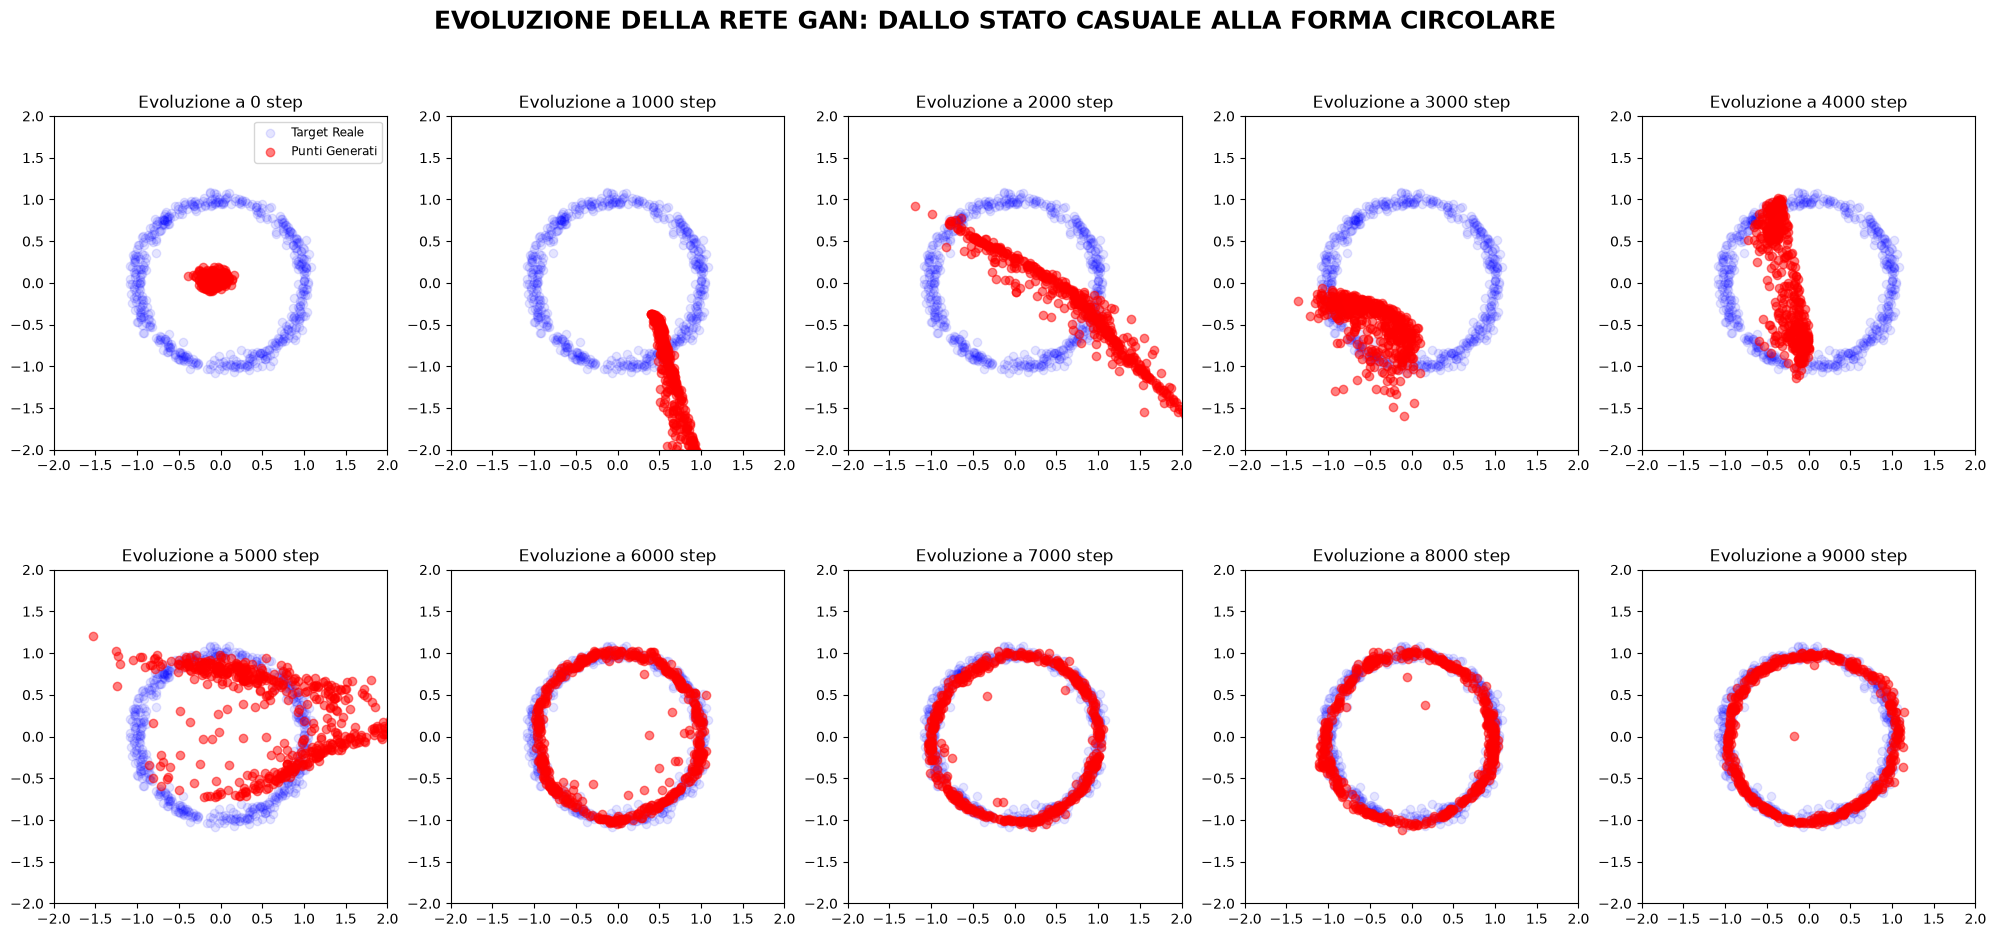

: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


# Definizione del Modello Generatore
# Il suo compito e' trasformare numeri casuali (spazio latente) in coordinate (x, y).
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        # Definiamo la struttura della rete neurale: una sequenza di strati lineari.
        self.net = nn.Sequential(
            # Primo strato: riceve il rumore (dimensione input_dim) e lo espande a 64 neuroni.
            nn.Linear(input_dim, 64),
            # Attivazione ReLU: introduce non-linearita' per permettere l'apprendimento di forme complesse.
            nn.ReLU(),
            # Secondo strato: mantiene la complessita' a 64 neuroni.
            nn.Linear(64, 64),
            nn.ReLU(),
            # Strato finale: riduce la dimensione a output_dim (che sara' 2, ovvero X e Y).
            nn.Linear(64, output_dim)
        )
    
    def forward(self, z):
        # La funzione forward definisce il passaggio del dato attraverso la rete.
        # Prende 'z' (rumore casuale) e restituisce una coppia di coordinate predetta.
        return self.net(z)

# Definizione del Modello Discriminatore
# Agisce come un poliziotto o un critico d'arte che deve smascherare i falsi.
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # La struttura e' simile al generatore ma termina con un singolo valore (probabilita').
        self.net = nn.Sequential(
            # Riceve coordinate (x, y) e inizia l'analisi.
            nn.Linear(input_dim, 64),
            # LeakyReLU previene il problema dei neuroni "morti", lasciando passare un piccolo segnale negativo.
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            # Strato finale: produce un unico numero.
            nn.Linear(32, 1),
            # Sigmoide: trasforma l'output in un valore tra 0 (sicuramente falso) e 1 (sicuramente vero).
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Riceve punti reali o generati e restituisce la probabilita' che siano reali.
        return self.net(x)

# Funzione per ottenere campioni reali (Il Target)
# Generiamo matematicamente dei punti che formano un cerchio con raggio 1.
def get_real_samples(n):
    # Generiamo 'n' angoli casuali tra 0 e 2*Pi greco.
    theta = torch.rand(n) * 2 * np.pi
    # Calcoliamo le coordinate X e Y usando le funzioni trigonometriche.
    x = torch.cos(theta)
    y = torch.sin(theta)
    # Uniamo i tensori e aggiungiamo un leggero rumore bianco per rendere i dati piu' naturali.
    data = torch.stack([x, y], dim=1) + torch.randn(n, 2) * 0.05
    return data

# --- FASE DI CONFIGURAZIONE ---

# Dimensione del vettore di rumore (spazio latente)
latent_dim = 10 
# Istanza dei due modelli
G = Generator(latent_dim, 2) # Il generatore accetta 10 numeri casuali e restituisce 2 coordinate.
D = Discriminator(2)        # Il discriminatore accetta 2 coordinate e restituisce un giudizio.

# Ottimizzatori: Adam e' un algoritmo efficiente per aggiornare i pesi delle reti.
# Gestiamo gli ottimizzatori separatamente perche' i modelli imparano in tempi diversi.
opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)

# Funzione di perdita: Binary Cross Entropy (BCE).
# Ideale per problemi di classificazione binaria (Vero/Falso).
criterion = nn.BCELoss()

# Liste per monitorare i progressi durante l'addestramento.
history = []
# Momenti prestabiliti in cui scattare una "foto" dello stato del generatore.
plot_snapshots = list(range(0, 10000, 1000))

print("Inizio addestramento competitivo...")
print("-" * 65)

# --- CICLO DI ADDESTRAMENTO ---

for epoch in range(10000):
    
    # --- FASE 1: ADDESTRAMENTO DEL DISCRIMINATORE ---
    # In questa fase vogliamo che D impari a distinguere bene il vero dal falso.
    opt_D.zero_grad() # Resetta i gradienti accumulati.
    
    # 1.1 Allenamento sui dati REALI
    real_data = get_real_samples(64) # Preleviamo un gruppo (batch) di 64 punti reali.
    d_real_decision = D(real_data) # D valuta i punti.
    # L'obiettivo e' che D risponda 1 (Real) per questi punti.
    d_loss_real = criterion(d_real_decision, torch.ones(64, 1))
    
    # 1.2 Allenamento sui dati FALSI (Generati)
    noise = torch.randn(64, latent_dim) # Generiamo rumore casuale.
    # G crea dei punti partendo dal rumore.
    # .detach() serve a non calcolare i gradienti per G in questa fase, poiche' stiamo allenando solo D.
    fake_data = G(noise).detach()
    d_fake_decision = D(fake_data) # D valuta i punti creati da G.
    # L'obiettivo e' che D risponda 0 (Fake) per questi punti.
    d_loss_fake = criterion(d_fake_decision, torch.zeros(64, 1))
    
    # Calcolo dell'errore totale di D e aggiornamento dei pesi.
    d_loss = d_loss_real + d_loss_fake
    d_loss.backward() # Calcola come cambiare i pesi per ridurre l'errore.
    opt_D.step()      # Applica il cambiamento dei pesi.
    
    # --- FASE 2: ADDESTRAMENTO DEL GENERATORE ---
    # In questa fase vogliamo che G impari a ingannare D.
    opt_G.zero_grad() # Resetta i gradienti.
    
    noise = torch.randn(64, latent_dim) # Generiamo nuovo rumore.
    gen_data = G(noise) # G crea nuovi punti.
    
    # G passa i suoi punti a D.
    # IMPORTANTE: Qui l'obiettivo di G e' che D risponda 1 (ovvero che creda che i falsi siano veri).
    g_loss = criterion(D(gen_data), torch.ones(64, 1))
    
    g_loss.backward() # Calcola come migliorare G per ingannare meglio D.
    opt_G.step()      # Applica il miglioramento a G.
    
    # Stampa dei progressi ogni 500 iterazioni.
    if epoch % 500 == 0:
        print(f"Iterazione {epoch:4d} | Perdita Discriminatore: {d_loss.item():.4f} | Perdita Generatore: {g_loss.item():.4f}")

    # Salvataggio dei punti generati per la visualizzazione finale.
    if epoch in plot_snapshots:
        with torch.no_grad(): # Non calcoliamo gradienti durante la generazione dei test.
            test_noise = torch.randn(500, latent_dim)
            generated_points = G(test_noise).numpy()
            history.append((epoch, generated_points))

print("-" * 65)
print("Addestramento completato. Preparazione dei grafici...")

# --- VISUALIZZAZIONE DEI RISULTATI ---

# Creiamo una griglia 2x5 per mostrare l'evoluzione in 10 passaggi.
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

# Otteniamo punti reali come riferimento visivo (Target).
real_p = get_real_samples(500).numpy()

for i, (ep, points) in enumerate(history):
    # Rappresentiamo i punti del cerchio reale in blu semitrasparente.
    axes[i].scatter(real_p[:, 0], real_p[:, 1], c='blue', alpha=0.1, label='Target Reale')
    # Rappresentiamo i punti creati dal Generatore in rosso.
    axes[i].scatter(points[:, 0], points[:, 1], c='red', alpha=0.5, label='Punti Generati')
    
    axes[i].set_title(f"Evoluzione a {ep} step")
    axes[i].set_xlim(-2, 2)
    axes[i].set_ylim(-2, 2)
    axes[i].set_aspect('equal') # Mantiene le proporzioni corrette (il cerchio non sembra un'ellisse).
    if i == 0: 
        axes[i].legend(loc='upper right', fontsize='small')

# Titolo generale e ottimizzazione del layout.
plt.suptitle("EVOLUZIONE DELLA RETE GAN: DALLO STATO CASUALE ALLA FORMA CIRCOLARE", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()